In [1]:
import sys
from pathlib import Path
base_path = Path('..')
sys.path.insert(0, str(base_path))

In [2]:
import warnings
warnings.filterwarnings(action='ignore')

import matplotlib.pyplot as plt
import numpy as np

from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score  

from erasers import MUtE

# Minimal Example

A minimal example to show how to use the method on a simple 2 blobs dataset. 

In [3]:
# Create a toy dataset
x, z = make_blobs(n_samples=2000, centers=2, n_features=2, random_state=42)
x = x - x.mean(axis=0) # center the data
x, x_test, z, z_test = train_test_split(x, z, test_size=0.2, random_state=42)

# Erasure (MUtE)
erasure_model = MUtE(nsteps=50) 
x_ = erasure_model.fit_transform(x,z) # learn the erasure function (including the concept classifier for routing)
x_test_ = erasure_model.transform(x_test)

# # Optimal Erasure (MUtE*)
# erasure_model = MUtE(nsteps=50, optimal_erasure=True) 
# erasure_model.fit(x,z) # learn the erasure function 
# x_ = erasure_model.transform(x, z) 
# x_test_ = erasure_model.transform(x_test, z_test)

# Counterfactual generation
z_cf = 1 - z
x_cf = erasure_model.inverse_transform(x_, z_cf)

# Evaluation (probing accuracy)
clf = MLPClassifier(random_state=42, early_stopping=True).fit(x,z)
print(f"Probing accuracy before erasure: {accuracy_score(z_test, clf.predict(x_test)):.4f}")
clf_ = MLPClassifier(random_state=42, early_stopping=True).fit(x_, z)
print(f"Probing accuracy after erasure: {accuracy_score(z_test, clf_.predict(x_test_)):.4f}")



Class predictor trained with accuracy (on train set): 0.99875


Iteration 50/50 complete.: 100%|██████████| 50/50 [00:00<00:00, 173.30it/s]


Probing accuracy before erasure: 1.0000
Probing accuracy after erasure: 0.4725


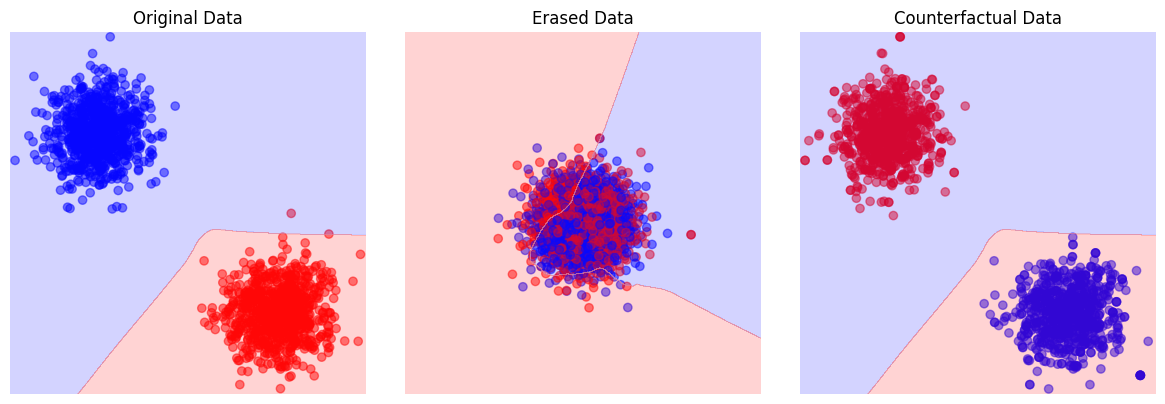

In [4]:
def plot_data(x, x_, x_cf, z, clf, clf_, colormap='bwr'):
    # Let's plot the 3 previous plots in a single figure with 3 subplots aligned horizontally and with the same size 3,4
    plt.figure(figsize=(12,4))

    # Calculate the common limits for all subplots
    all_data = [x, x_, x_cf]
    x_eps, y_eps = 0.2, 0.2
    x_min_all = min([d[:,0].min() for d in all_data]) - x_eps
    x_max_all = max([d[:,0].max() for d in all_data]) + x_eps
    y_min_all = min([d[:,1].min() for d in all_data]) - y_eps
    y_max_all = max([d[:,1].max() for d in all_data]) + y_eps

    plt.subplot(1, 3, 1)
    plt.scatter(x[:,0], x[:,1], c=z, cmap=colormap, alpha=0.5)
    plt.title("Original Data")

    plt.subplot(1, 3, 2)
    plt.scatter(x_[:,0], x_[:,1], c=z, cmap=colormap, alpha=0.5)
    plt.title("Erased Data")

    plt.subplot(1, 3, 3)
    plt.scatter(x_cf[:,0], x_cf[:,1], c=z, cmap=colormap, alpha=0.5)
    plt.title("Counterfactual Data")

    # draw the decision boundary of the classifier
    xx, yy = np.meshgrid(np.linspace(x_min_all, x_max_all, 1000), np.linspace(y_min_all, y_max_all, 1000))
    if clf is not None:
        for i in [1,3]:
            plt.subplot(1, 3, i)
            Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
            Z = Z.reshape(xx.shape) 
            plt.contourf(xx, yy, Z, alpha=0.2, cmap=colormap)
    plt.subplot(1, 3, 2)
    Z = clf_.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, alpha=0.2, cmap=colormap)

    # Apply consistent limits and formatting to each subplot
    for i in range(1, 4):
        plt.subplot(1, 3, i)    
        plt.xlim(x_min_all, x_max_all)
        plt.ylim(y_min_all, y_max_all)
        plt.gca().set_aspect('equal')
        plt.xticks([])
        plt.yticks([])

        # remove the black border around the plot
        plt.gca().spines['top'].set_visible(False)
        plt.gca().spines['right'].set_visible(False)
        plt.gca().spines['bottom'].set_visible(False)  
        plt.gca().spines['left'].set_visible(False)

    plt.tight_layout()
    plt.show()

plot_data(x, x_, x_cf, z, clf, clf_)

A minimal example to show how to use the method on a simple 4 blobs dataset. 

Class predictor trained with accuracy (on train set): 0.999375


  0%|          | 0/50 [00:00<?, ?it/s]

Iteration 50/50 complete.: 100%|██████████| 50/50 [00:00<00:00, 195.54it/s]


Probing accuracy before erasure: 1.0000
Probing accuracy after erasure: 0.2000


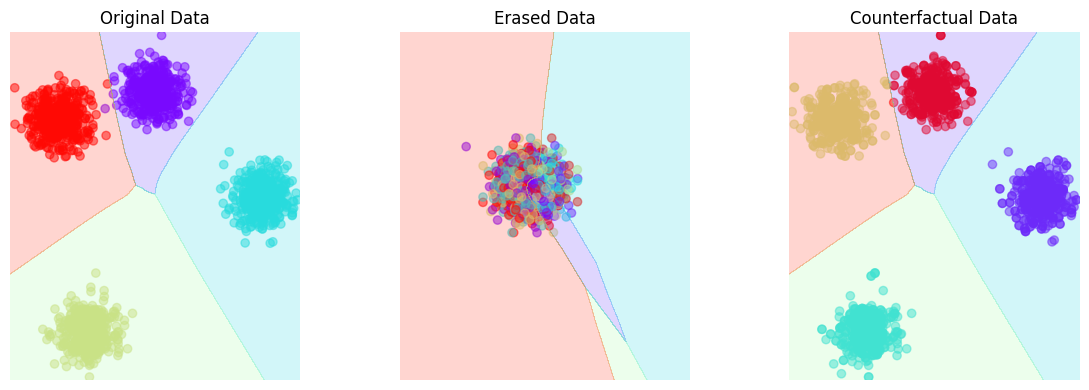

In [5]:
# Create a toy dataset
x, z = make_blobs(n_samples=2000, centers=4, n_features=2, random_state=42)
x = x - x.mean(axis=0) # center the data
x, x_test, z, z_test = train_test_split(x, z, test_size=0.2, random_state=42)

# Erasure (MUtE)
erasure_model = MUtE(nsteps=50) 
x_ = erasure_model.fit_transform(x,z) # learn the erasure function (including the concept classifier for routing)
x_test_ = erasure_model.transform(x_test)

# # Optimal Erasure (MUtE*)
# erasure_model = MUtE(nsteps=50, optimal_erasure=True) 
# erasure_model.fit(x,z) # learn the erasure function 
# x_ = erasure_model.transform(x, z) 
# x_test_ = erasure_model.transform(x_test, z_test)

# Counterfactual generation
z_cf = (z+1) % 4
x_cf = erasure_model.inverse_transform(x_, z_cf)

# Evaluation (probing accuracy)
clf = MLPClassifier(random_state=42, early_stopping=True).fit(x,z)
print(f"Probing accuracy before erasure: {accuracy_score(z_test, clf.predict(x_test)):.4f}")
clf_ = MLPClassifier(random_state=42, early_stopping=True).fit(x_, z)
print(f"Probing accuracy after erasure: {accuracy_score(z_test, clf_.predict(x_test_)):.4f}")

plot_data(x, x_, x_cf, z, clf, clf_, colormap='rainbow')

# Impact of the routing classifier

The results below show that the default routing clasifier $\eta^*$  of the MUtE eraser has an accuracy of $86\%$ which, as a consequence, produces artifacts corresponding to misclassified samples.

Class predictor trained with accuracy (on train set): 0.99625


Iteration 200/200 complete.: 100%|██████████| 200/200 [00:00<00:00, 319.19it/s]


Probing accuracy after erasure: 0.5100


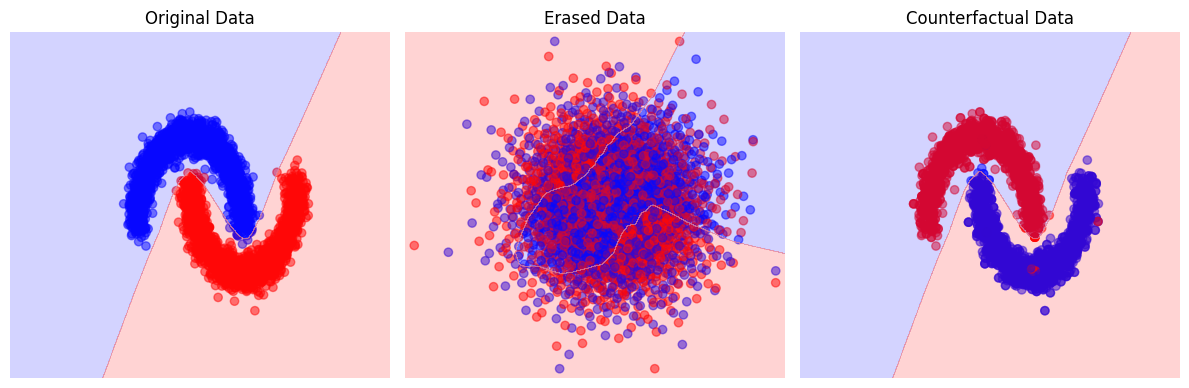

In [6]:
from sklearn.datasets import make_moons

# Create a toy dataset
x, z = make_moons(n_samples=4000, noise=0.1, random_state=42)
x = x - x.mean(axis=0) # center the data
# whiten the array x to have unit variance
x = (x - x.mean(axis=0)) / x.std(axis=0)
x, x_test, z, z_test = train_test_split(x, z, test_size=0.2, random_state=42)

# Erasure (MUtE)
erasure_model = MUtE(nsteps=200, bins=1000) 
x_ = erasure_model.fit_transform(x,z) # learn the erasure function (including the concept classifier for routing)
x_test_ = erasure_model.transform(x_test)

# Counterfactual generation
z_cf = 1 - erasure_model.class_clf.predict(x)
x_cf = erasure_model.inverse_transform(x_, z_cf)

# Evaluation (probing accuracy)
clf_ = MLPClassifier(random_state=42, early_stopping=True).fit(x_, z)
print(f"Probing accuracy after erasure: {accuracy_score(z_test, clf_.predict(x_test_)):.4f}")

plot_data(x, x_, x_cf, z, erasure_model.class_clf, clf_)

Should a perfect oracle $\eta^*$ be available at test time, one can use the theoretical MUtE* function, for which no sample is misclassified, and the routing is not noisy.

Iteration 200/200 complete.: 100%|██████████| 200/200 [00:00<00:00, 316.70it/s]


Probing accuracy after erasure: 0.5138


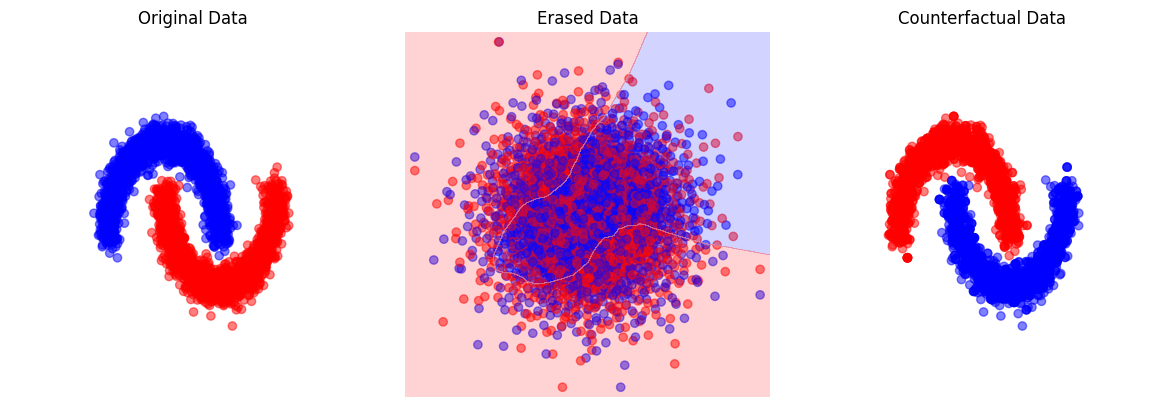

In [7]:
# Optimal Erasure (MUtE*)
erasure_model = MUtE(nsteps=200, optimal_erasure=True) 
erasure_model.fit(x,z) # learn the erasure function 
x_ = erasure_model.transform(x, z) 
x_test_ = erasure_model.transform(x_test, z_test)

# Counterfactual generation
z_cf = 1 - z
x_cf = erasure_model.inverse_transform(x_, z_cf)

# Evaluation (probing accuracy)
clf_ = MLPClassifier(random_state=42, early_stopping=True).fit(x_, z)
print(f"Probing accuracy after erasure: {accuracy_score(z_test, clf_.predict(x_test_)):.4f}")

plot_data(x, x_, x_cf, z, erasure_model.class_clf, clf_)

The MUtE class allows for setting an independently trained router by passing it as an argument when fitting the model.

Probing accuracy before erasure: 0.9975


Iteration 200/200 complete.: 100%|██████████| 200/200 [00:00<00:00, 319.33it/s]


Probing accuracy after erasure: 0.5138


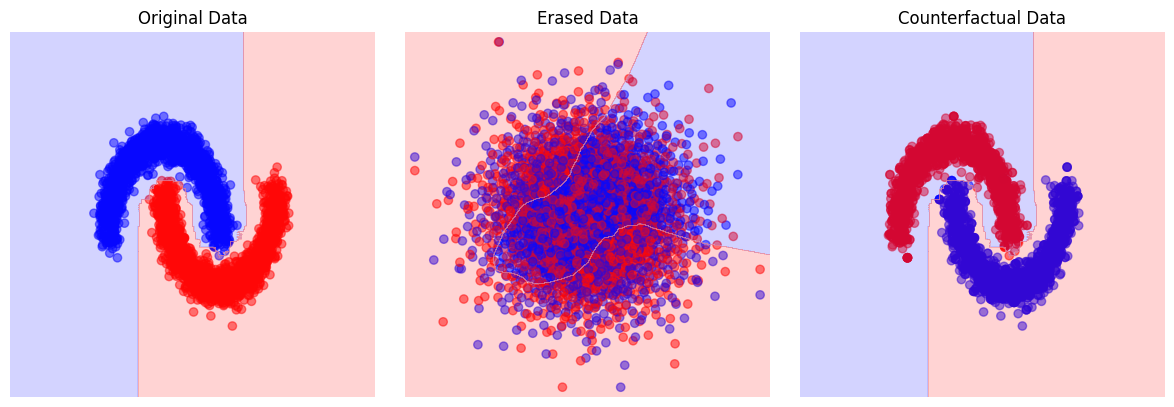

In [8]:
# Let's train a classifier on the original data (for example a random forest classifier)
from sklearn.ensemble import RandomForestClassifier
clf = RandomForestClassifier(random_state=42).fit(x,z)
# from sklearn.linear_model import SGDClassifier
# clf  = SGDClassifier(loss='hinge', random_state=42).fit(x, z)
print(f"Probing accuracy before erasure: {accuracy_score(z_test, clf.predict(x_test)):.4f}")


# Initialize the erasure model with optimal erasure set to False
erasure_model = MUtE(nsteps=200, optimal_erasure=False)
erasure_model.fit(x, z, class_predictor=clf) # learn the erasure function
x_ = erasure_model.transform(x) 
x_test_ = erasure_model.transform(x_test)

# Counterfactual generation
z_cf = 1 - z
x_cf = erasure_model.inverse_transform(x_, z_cf)

# Evaluation (probing accuracy)
clf_ = MLPClassifier(random_state=42, early_stopping=True).fit(x_, z)
print(f"Probing accuracy after erasure: {accuracy_score(z_test, clf_.predict(x_test_)):.4f}")

plot_data(x, x_, x_cf, z, erasure_model.class_clf, clf_)



# Evaluate the model during fitting using validation data

In [9]:
import torch
from sklearn.metrics import accuracy_score
from sklearn.neural_network import MLPClassifier
def eval_probing_accuracy(x, z, x_val, z_val):
    x = x.detach().cpu().numpy() if torch.is_tensor(x) else x
    z = z.detach().cpu().numpy() if torch.is_tensor(z) else z
    x_val = x_val.detach().cpu().numpy() if torch.is_tensor(x_val) else x_val
    z_val = z_val.detach().cpu().numpy() if torch.is_tensor(z_val) else z_val
    # select at most 5000 training samples
    if len(x) > 5000:
        # select random 5000 samples
        indices = np.random.choice(len(x), 5000, replace=False)
        x = x[indices]
        z = z[indices]
    clfs = [MLPClassifier(random_state=42+i, early_stopping=True) for i in range(10)]
    scores = [accuracy_score(z_val, clf.fit(x, z).predict(x_val)) for clf in clfs]
    return sum(scores) / len(scores)

  0%|          | 0/100 [00:00<?, ?it/s]

Iteration 100/100 complete.: 100%|██████████| 100/100 [00:18<00:00,  5.53it/s]


Probing accuracy after erasure: 0.4925
Majority class: 1
Majority class ratio: 0.5059


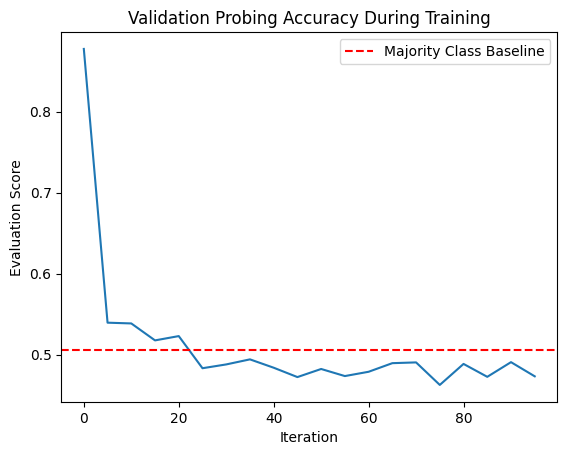

In [10]:
# Select 10% of the data for validation
val_size = int(0.1 * len(x))
x_val = x[:val_size]
z_val = z[:val_size]
x = x[val_size:]
z = z[val_size:]

# Initialize the erasure model with optimal erasure set to False
erasure_model = MUtE(nsteps=100, optimal_erasure=False)
erasure_model.fit(x, z, class_predictor=clf, eval_function=eval_probing_accuracy, eval_every=5, validation_data=x_val, validation_labels=z_val) # learn the erasure function
x_ = erasure_model.transform(x) 
x_test_ = erasure_model.transform(x_test)


# Evaluation (probing accuracy)
clf_ = MLPClassifier(random_state=42, early_stopping=True).fit(x_, z)
print(f"Probing accuracy after erasure: {accuracy_score(z_test, clf_.predict(x_test_)):.4f}")



eval_scores = erasure_model.evals
# draw the evaluation scores during training
import matplotlib.pyplot as plt
plt.plot([eval_score[0] for eval_score in eval_scores],[eval_score[1] for eval_score in eval_scores])
# display the majority class label baseline
majority_class = max(set(z), key=list(z).count)
majority_ratio = list(z).count(majority_class) / len(z)
print(f"Majority class: {majority_class}")
print(f"Majority class ratio: {majority_ratio:.4f}")
plt.axhline(y=majority_ratio, color='r', linestyle='--', label='Majority Class Baseline')
plt.legend()
plt.xlabel('Iteration')
plt.ylabel('Evaluation Score')
plt.title('Validation Probing Accuracy During Training')
plt.show()



# GloVe Embeddings

First, using the validation set, we confirm that post-erasure probing accuracy drops rapidly to chance level. 

Erasing gender from GloVe requires only about 5 MUtE iterations.


Majority class: 0
Majority class ratio: 0.3415
Class predictor trained with accuracy (on train set): 0.9998144195972906


Iteration 10/10 complete.: 100%|██████████| 10/10 [00:38<00:00,  3.87s/it]


Probing accuracy after erasure: 0.3267


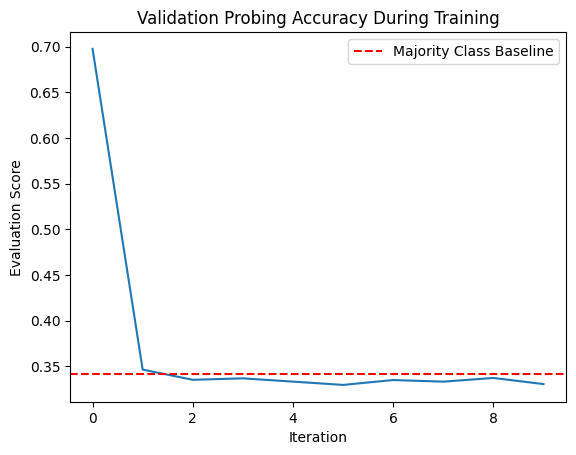

In [11]:
from data.utils import load_data
x, z, _, x_val, z_val, _, x_test, z_test, _, z_values, _ = load_data("GloVe", base_path='../')
# class labels are 0: female, 1: male, 2: neutral

# Display the majority class label baseline
majority_class = max(set(z), key=list(z).count)
majority_ratio = list(z).count(majority_class) / len(z)
print(f"Majority class: {majority_class}")
print(f"Majority class ratio: {majority_ratio:.4f}")

# Train the erasure model
erasure_model = MUtE(nsteps=10)
erasure_model.fit(x, z, eval_function=eval_probing_accuracy, eval_every=1, validation_data=x_val, validation_labels=z_val) # learn the erasure function
x_ = erasure_model.transform(x) 
x_test_ = erasure_model.transform(x_test)
eval_scores = erasure_model.evals # evaluation scores during training

# Evaluation (probing accuracy)
clf_ = MLPClassifier(random_state=42, early_stopping=True).fit(x_, z)
print(f"Probing accuracy after erasure: {accuracy_score(z_test, clf_.predict(x_test_)):.4f}")


# Draw the evaluation scores during training
import matplotlib.pyplot as plt
plt.plot([eval_score[0] for eval_score in eval_scores],[eval_score[1] for eval_score in eval_scores])
plt.axhline(y=majority_ratio, color='r', linestyle='--', label='Majority Class Baseline')
plt.legend()
plt.xlabel('Iteration')
plt.ylabel('Evaluation Score')
plt.title('Validation Probing Accuracy During Training')
plt.show()

Second, for a subset of training words labeled as female and explicitly related to the female gender, we compute their counterfactual representations using MUtE. For each word, we retrieve the five nearest neighbors by cosine similarity from the 150k-word GloVe vocabulary, ranked in descending order. 

The results show that natural counterfactuals are retrieved when they exist (e.g., her $\rightarrow$ his, sister $\rightarrow$ brother, policewoman $\rightarrow$ policeman, lesbian $\rightarrow$ gay), whereas semantically close alternatives are recovered when no direct counterfactual is available (e.g., panties $\rightarrow$ shorts).

In [12]:
import pickle
with open('../data/GloVe/fem_words.pkl', "rb") as f:
    female_words = pickle.load(f)

with open('../data/GloVe/glove-top-150k.pickle', "rb") as f:
    data = pickle.load(f)
glove_150k = dict(zip(data['words'], data['vecs']))
words_150k = list(glove_150k.keys())
x_150k = np.array(list(glove_150k.values()))
# use the classifier of the eraser to classify words based on their GloVe embeddings
z_150k = erasure_model.class_clf.predict(x_150k)

# Here are words that in the female train set that are obviously female-related
feminine_occupations = [
    "actress", "ballerina", "songstress", "authoress", "governess", 
    "midwife", "waitress", "comedienne", "maid", "seamstress", 
    "policewoman", "congresswoman", "stewardess", "businesswoman", "saleswoman", 
    "landlady", "assemblywoman", "showgirl", "dominatrix", "doula"
] 

gender_markers = [
    "she", "her", "hers", "herself", "woman", 
    "women", "girl", "girls", "lady", "ladies", 
    "mother", "grandmother", "daughter", "sister", "aunt", 
    "niece", "female", "females", "miss", "mrs"
] 

general_associations = [
    "pregnant", "motherhood", "lesbian", "maternity", "estrogen", 
    "uterus", "ovaries", "breasts", "menstrual", "feminism", 
    "feminine", "makeup", "bikini", "lingerie", "bra", 
    "pantyhose", "corset", "lipstick", "panties", "ovulation"
] 


# We will use the cosine similarity to compare the original and counterfactual embeddings
calc_distances = lambda x, X : 1 - (X @ x) / (np.linalg.norm(x) * np.linalg.norm(X, axis=1))

# Let's extract the male and neutral words from the 150k vocabulary
z_150k_filtered = z_150k != 0 # 0 is female
x_150k_filtered = x_150k[z_150k_filtered]
selected_words_filtered = [words_150k[i] for i in range(len(words_150k)) if z_150k_filtered[i]]

list_names = ["Feminine Occupations", "Gender Markers", "General Associations"]
for list_name, words in zip(list_names, [
    feminine_occupations,
    gender_markers,
    general_associations
]):
    words_emb = np.array([female_words[word] for word in words])
    words_emb_cf = erasure_model.inverse_transform(erasure_model.transform(words_emb), np.ones_like(words_emb[:, 0]))
    print(list_name, ':')
    for i in range(len(words)):
        distances = calc_distances(words_emb[i], x_150k_filtered)
        closest_indices = np.argsort(distances)[:5]
        closest_words = [selected_words_filtered[j] for j in closest_indices]
        print(f"{words[i]}", "-->", ", ".join(closest_words))
    print()


Feminine Occupations :
actress --> actor, movie, star, hollywood, stars
ballerina --> nutcracker, shoe, flops, ornament, suede
songstress --> crooner, r&b, songwriter, vocalist, multi-instrumentalist
authoress --> novelist, essayist, diarist, dramatist, humorist
governess --> schoolmaster, suitor, dutiful, disciplinarian, stenographer
midwife --> doctor, ob, physician, anesthesiologist, pharmacist
waitress --> waiter, bartender, waiters, waitstaff, cashier
comedienne --> comedian, humorist, funnyman, talk-show, playwright
maid --> servant, cleaning, service, slave, servants
seamstress --> tailors, tailor, dressmakers, gunsmith, alterations
policewoman --> policeman, policemen, cop, plainclothes, mountie
congresswoman --> rep., congressman, senator, sen., congressmen
stewardess --> waiter, co-pilot, airline, steward, purser
businesswoman --> businessman, businessperson, businesspeople, entrepreneur, businessmen
saleswoman --> salesman, salesperson, salesmen, shopkeeper, salespeople
land

# DIAL (deepmoji)

Class predictor trained with accuracy (on train set): 0.851175


Iteration 100/100 complete.: 100%|██████████| 100/100 [03:07<00:00,  1.87s/it]


Majority class: 0
Majority class ratio: 0.5000
Probing accuracy after erasure: 0.5031


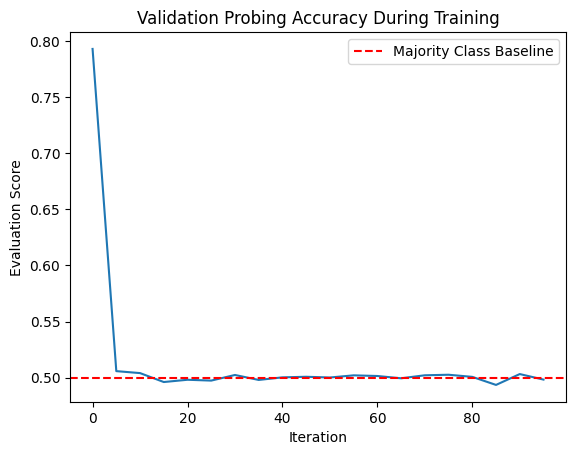

In [22]:
from data.utils import load_data
x, z, _, x_val, z_val, _, x_test, z_test, _, z_values, _ = load_data("deepmoji", base_path='../')

# Initialize the erasure model with optimal erasure set to False
erasure_model = MUtE(nsteps=100, optimal_erasure=False)
erasure_model.fit(x, z, eval_function=eval_probing_accuracy, eval_every=5, validation_data=x_val, validation_labels=z_val) # learn the erasure function
x_ = erasure_model.transform(x) 
x_test_ = erasure_model.transform(x_test)

majority_class = max(set(z), key=list(z).count)
majority_ratio = list(z).count(majority_class) / len(z)
print(f"Majority class: {majority_class}")
print(f"Majority class ratio: {majority_ratio:.4f}")


# Evaluation (probing accuracy)
clf_ = MLPClassifier(random_state=42, early_stopping=True).fit(x_, z)
print(f"Probing accuracy after erasure: {accuracy_score(z_test, clf_.predict(x_test_)):.4f}")



eval_scores = erasure_model.evals
# draw the evaluation scores during training
import matplotlib.pyplot as plt
plt.plot([eval_score[0] for eval_score in eval_scores],[eval_score[1] for eval_score in eval_scores])
# display the majority class label baseline
plt.axhline(y=majority_ratio, color='r', linestyle='--', label='Majority Class Baseline')
plt.legend()
plt.xlabel('Iteration')
plt.ylabel('Evaluation Score')
plt.title('Validation Probing Accuracy During Training')
plt.show()

# Beyond NLP: an example using the digits dataset

MUtE can also be applied beyond NLP settings. Using a handwritten digit dataset, we demonstrate qualitatively that MUtE can serve as an effective tool for data augmentation.

Furthermore, analyzing the 2D PCA projections of both original and counterfactual samples—specifically the trajectories connecting original representations to their counterfactual counterparts—reveals that MUtE induces a translational bias.

In [17]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA

nclasses = 10
digits = load_digits(n_class=nclasses)
x_orig, z = digits.data, digits.target
x_orig, x_test_orig, z, z_test = train_test_split(x_orig, z, test_size=0.2, random_state=42)
pca_orig = PCA(n_components=0.99, svd_solver='full')
x = pca_orig.fit_transform(x_orig) # remove the noise
x_test = pca_orig.transform(x_test_orig) 

print("Shapes after initial PCA (x, z, x_test, z_test):", x.shape, z.shape, x_test.shape, z_test.shape)

# Create counterfactual class labels by randomly shifting the original labels
z_cf = (z + np.random.randint(1, nclasses, size=z.shape)) % nclasses
assert sum(z == z_cf) == 0, "No original label should match its counterfactual label"

erasure_model = MUtE(nsteps=50)
x_erased = erasure_model.fit_transform(x, z)
x_cf = erasure_model.inverse_transform(x_erased, z_cf)

x = pca_orig.inverse_transform(x)
x_cf = pca_orig.inverse_transform(x_cf)

Shapes after initial PCA (x, z, x_test, z_test): (1437, 41) (1437,) (360, 41) (360,)
Class predictor trained with accuracy (on train set): 0.9937369519832986


Iteration 50/50 complete.: 100%|██████████| 50/50 [00:08<00:00,  5.95it/s]


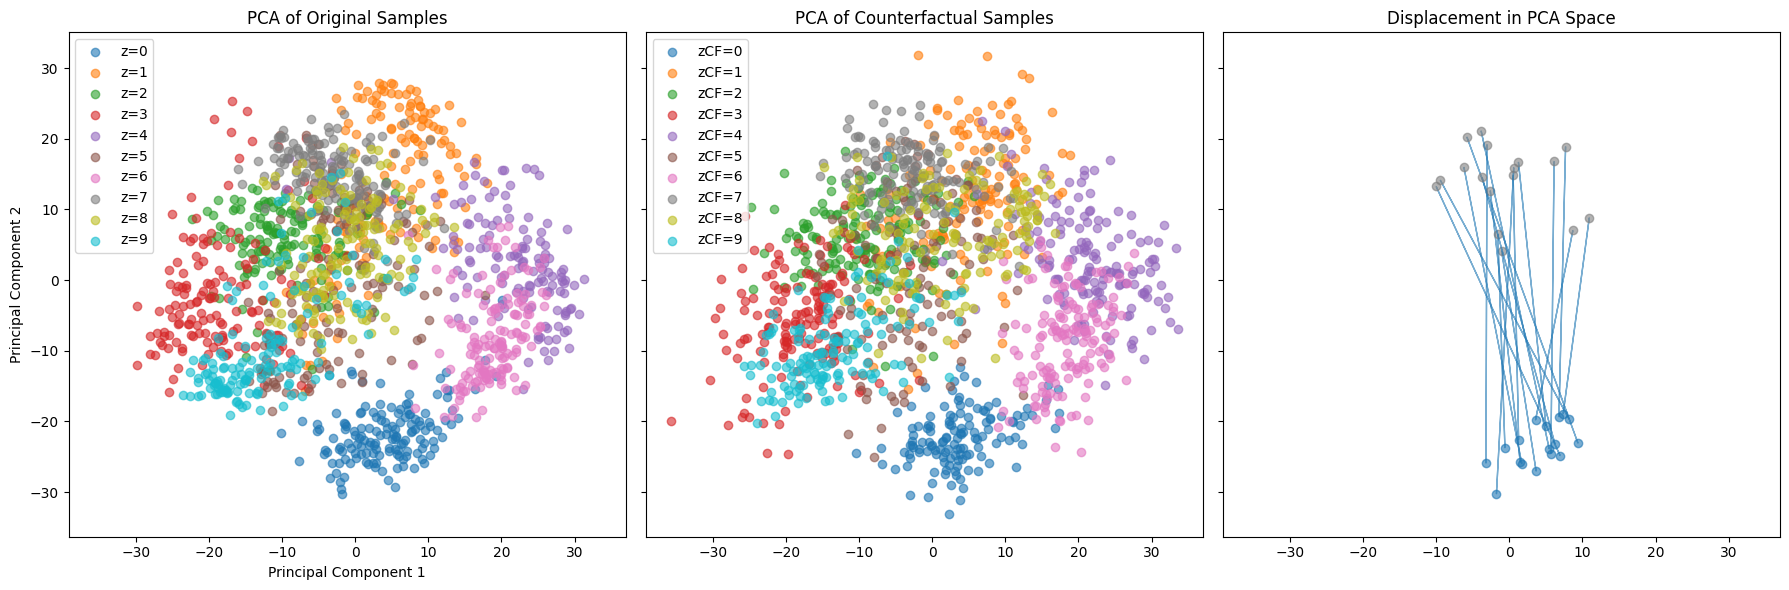

In [18]:
from sklearn.decomposition import PCA
pca_digits = PCA(n_components=2)
x_pca = pca_digits.fit_transform(x_orig)
x_cf_pca = pca_digits.transform(x_cf)

fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(18, 6), sharey=True, sharex=True)

# PCA of original samples
for i in range(nclasses):
    axs[0].scatter(x_pca[z == i, 0], x_pca[z == i, 1], label=f"z={i}", alpha=0.6)
axs[0].set_title("PCA of Original Samples")
axs[0].set_xlabel("Principal Component 1")
axs[0].set_ylabel("Principal Component 2")
axs[0].legend()

# PCA of counterfactual samples
for i in range(nclasses):
    axs[1].scatter(x_cf_pca[z_cf == i, 0], x_cf_pca[z_cf == i, 1], label=f"zCF={i}", alpha=0.6)
axs[1].set_title("PCA of Counterfactual Samples")
axs[1].legend()

# Displacement in PCA space using arrows
# select only 20 samples for only one pairs of classes i, j (i \neq j)
i, j = 0, 7  # select a pair of classes to visualize the displacement
idx_to_plot = []
idx = np.where((z == i) & (z_cf == j))[0][:20]  # select only the first 10 samples of each selected class
idx_to_plot.extend(idx)
for i in idx_to_plot:
    axs[2].arrow(x_pca[i, 0], x_pca[i, 1], x_cf_pca[i, 0] - x_pca[i, 0], x_cf_pca[i, 1] - x_pca[i, 1], color=plt.cm.tab10(z[i] / nclasses), alpha=0.6) 
    axs[2].scatter(x_cf_pca[i, 0], x_cf_pca[i, 1], color=plt.cm.tab10(z_cf[i] / nclasses), alpha=0.6)
    axs[2].scatter(x_pca[i, 0], x_pca[i, 1], color=plt.cm.tab10(z[i] / nclasses), alpha=0.6)
axs[2].set_title("Displacement in PCA Space")
fig.tight_layout()

plt.show()

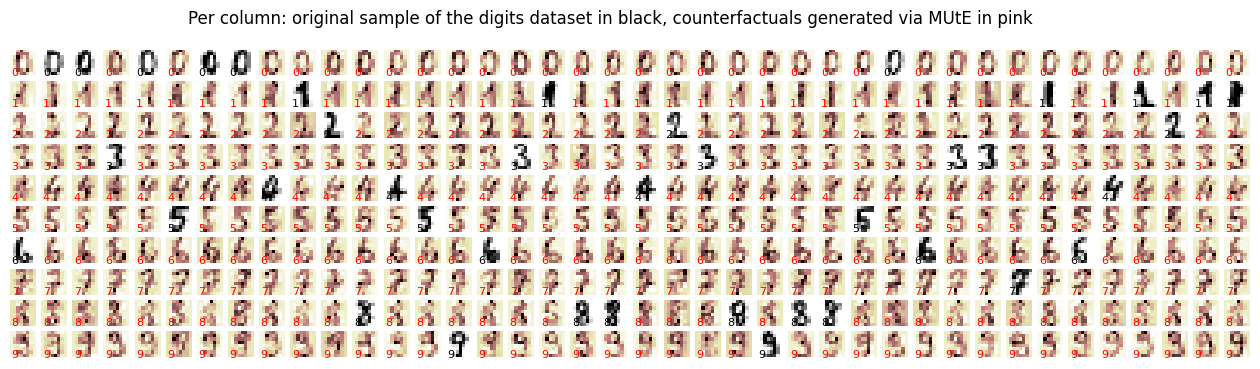

In [19]:
nexample = 40
# We will create conterfactuals for the first 40 digits in the dataset for each counterfactual class
# First create counterfactual labels
z_cf_all = np.array([[i]*nexample for i in range(10)]).ravel()
z_orig_copied = np.array([z[:nexample] for _ in range(10)]).ravel()
mask = z_cf_all == z_orig_copied
x_selected = np.empty((nexample*nclasses, x.shape[1]))
# if the original class and the counterfactual class are the same, we keep the original example
x_selected[mask] = np.tile(x_orig[:nexample], (nclasses, 1))[mask]
# now generate the counterfactuals for the remaining examples
x_repeated_cf =  np.tile(x_orig[:nexample], (nclasses, 1))
x_repeated_cf = pca_orig.transform(x_repeated_cf)
x_repeated_cf = erasure_model.transform(x_repeated_cf)
x_repeated_cf = erasure_model.inverse_transform(x_repeated_cf, z_cf_all)
x_repeated_cf = pca_orig.inverse_transform(x_repeated_cf)
x_selected[~mask] = x_repeated_cf[~mask]


import matplotlib.pyplot as plt
fig, axs = plt.subplots(nrows=nclasses, ncols=nexample, figsize=(16, 4))
for idx, ax in enumerate(axs.ravel()):
    if mask[idx]:
        ax.imshow(x_selected[idx].reshape((8, 8)), cmap=plt.cm.gray_r)
        # display the original class number as an annotation on the bottom left of the image
        ax.text(0, 8, f"{z_orig_copied[idx]}", fontsize=8, color='black', ha='left', va='bottom')
    else:
        ax.imshow(x_selected[idx].reshape((8, 8)), cmap=plt.cm.pink_r)
        # display the target class number as an annotation on the bottom left of the image
        ax.text(0, 8, f"{z_cf_all[idx]}", fontsize=8, color='red', ha='left', va='bottom')
    ax.axis("off")
_ = fig.suptitle("Per column: original sample of the digits dataset in black, counterfactuals generated via MUtE in pink", fontsize=12)
